<a href="https://colab.research.google.com/github/RamanBaghel/Machine-Learning-Excercise/blob/main/Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 4: Boosting

In [2]:
import sys, os
if 'google.colab' in sys.modules:
  if os.getcwd() == '/content':
    !git clone 'https://github.com/inb-luebeck/cs5450.git'
    os.chdir('cs5450')

Cloning into 'cs5450'...
remote: Enumerating objects: 130, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 130 (delta 40), reused 38 (delta 17), pack-reused 61 (from 1)
Receiving objects: 100% (130/130), 28.17 MiB | 29.05 MiB/s, done.
Resolving deltas: 100% (67/67), done.


## Exercise 4.1:

In this exercise, we will use the adaptive boosting algorithm [AdaBoost](https://en.wikipedia.org/wiki/AdaBoost) to combine multiple weak classification models to one strong classifier for a two-class classification problem
on a two-dimensional dataset. Our simple classifier will be a threshold on either dimension, dividing the dataset into two classes.
The data will be generated with the provided function genData. Each row in the generated matrix data corresponds to one observation and each column to a single feature. The generated vector labels contains the corresponding desired output value of the two-class classification problem.

When done correctly, your code should do the following:
1. Create a random dataset.
2. Iterativly, do the following:
    <br>a) Train another weak classification model.
    <br>b) Compute the predictions of the weak classifier.
    <br>c) Calculate the weighted training error of the weak classifier.
    <br>d) Update the distribution of weights assigned to each data sample.
    <br>e) Combine all the weak classification models to one strong classifier.
    <br>f) Calculate the error of the strong classifier.
    <br>g) Compute the decision boundary of the strong classifier.
3. Plot the error of the strong classifier for each iteration.
4. Create an animation which shows how the decision boundary of the strong classifiers changes over time.

In case you are struggeling with the task, here are some helpful tips and hints:
1. Useful functions : gen_data, train_classifier, get_decision_boundary
2. Good initial values are: n_samples=2000, n_classifiers=200.


In [3]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
%matplotlib inline

def gen_data(n_samples):
    """
    Generate data.

    INPUT:
        n_samples : number of samples to generate (observations)

    OUTPUT:
       data : 2D data points
       labels : ndarray of class labels with integer values -1 or 1
    """

    data = np.random.random((n_samples,2)) - 0.5
    labels = np.linalg.norm(data, axis=1) < 0.4
    labels = (labels.astype(int) * 2) - 1

    return data, labels

class Classifier(object):

    def __init__(self, dimension=0, threshold=0., sign=1):
        super().__init__()
        self.dimension = dimension
        self.threshold = threshold
        self.sign = sign

    def predict(self, data):
        """
        Predict new data

        INPUT:d
            data : 2D data points

        OUTPUT:
            estimated labels
        """
        return self.sign * ((data[:, self.dimension] >= self.threshold).astype(int) * 2 - 1)

def train_classifier(classifier, data, targets, weights):
    """
    Predict new data

    INPUT:
        classifier : classifier to train
        data : 2D data points
        targets : ndarray of class labels with integer values -1 or 1
        weights: weights assigned to each data sample

    OUTPUT:
        classifier : trained classifier
    """
    min_error = np.inf
    dimensions = [0, 1]
    thresholds = np.linspace(-0.5, 0.5, 11)
    signs = [-1, 1]
    best_parameters = (0, 0., 1)

    for d in dimensions:
        classifier.dimension = d
        for t in thresholds:
            classifier.threshold = t
            for s in signs:
                classifier.sign = s

                predictions = classifier.predict(data)
                error = (weights * (predictions != targets).astype(int)).sum()

                if error < min_error:
                    best_parameters = (d, t, s)
                    min_error = error

    classifier.dimension = best_parameters[0]
    classifier.threshold = best_parameters[1]
    classifier.sign = best_parameters[2]
    return classifier

class Animation(object):
    """
    Creates animation object to visualize the decision boundaries of the strong classifier.
    """
    def __init__(self, data, labels, decision_boundaries):
        """
        INPUT:
            data : 2D data points
            labels : ndarray of class labels with integer values -1 or 1
            decision_boundaries: ndarray of shape (n_classifiers, n**2) with prediction results for an (n x n) grid.
        """
        super().__init__()
        self.decision_boundaries = decision_boundaries

        fig, ax = plt.subplots(figsize=(8, 6))

        # plot data points
        ax.scatter(data[labels==-1,1], data[labels==-1,0], c=np.array([[0.5, 0.7, 1.]]), marker='o')
        ax.scatter(data[labels==1,1], data[labels==1,0], c=np.array([[1., 0.6, 0.6]]), marker='x')
        # write axis labels
        ax.set_xlabel('x')
        ax.set_ylabel('y')

        x_lim = ax.get_xlim()
        y_lim = ax.get_ylim()
        # Reshape the 1D decision boundary to 2D (12,12) for imshow
        im = ax.imshow(decision_boundaries[0].reshape(12,12), extent=(-0.55,0.55,-0.55,0.55), interpolation='none', cmap='jet', origin='lower', vmin=-1, vmax=1)
        ax.set_xlim(x_lim)
        ax.set_ylim(y_lim)

        fig.colorbar(im)

        self.fig = fig
        self.im = im

    def animate(self, i):
        """
        animate function for FuncAnimation

        Input:
            i : integer for indexing
        """
        # Reshape the 1D decision boundary to 2D (12,12) for imshow
        self.im.set_array(self.decision_boundaries[i].reshape(12,12))

    def get_animation(self):
        """
        Return animation object which holds the animation
        """
        return FuncAnimation(self.fig, self.animate, frames=len(self.decision_boundaries))

def get_decision_boundary(data, classifiers, alphas):
    """
    Create the decision boundary of a strong classifier. The function creates a 12 x 12 grid and a strong classifier. For every location in the grid the prediction is obtained and returned.

    INPUT:
        data : 2D data points
        classifiers : list of trained classifiers
        alphas : ndarray with weights of the classifiers

    OUTPUT:
        decision_boundary : ndarray of shape (n_classifiers, 12**2) with prediction results for an (12 x 12) grid.
    """

    n_classifiers = len(classifiers)

    # create grid
    nx = 12
    ny = 12
    x = np.linspace(-0.5, 0.5, nx)
    y = np.linspace(-0.5, 0.5, ny)
    xx, yy = np.meshgrid(x, y)
    xy = np.stack((xx.reshape(-1),yy.reshape(-1)), 1)

    # classify grid points
    predictions = np.zeros((ny * nx, n_classifiers))
    for i, classifier in enumerate(classifiers):
        prediction = classifier.predict(xy)
        predictions[:,i] = prediction
    decision_boundary = ((alphas[None,:n_classifiers] * predictions).sum(axis=1) > 0).astype(int) * 2 - 1
    decision_boundary = decision_boundary.reshape(ny, nx)

    return decision_boundary

In [4]:
"""
Choose hyperparameters
"""
# TODO set number of samples (observations)
n_samples = 2000

# TODO set number of rounds
n_classifiers = 200

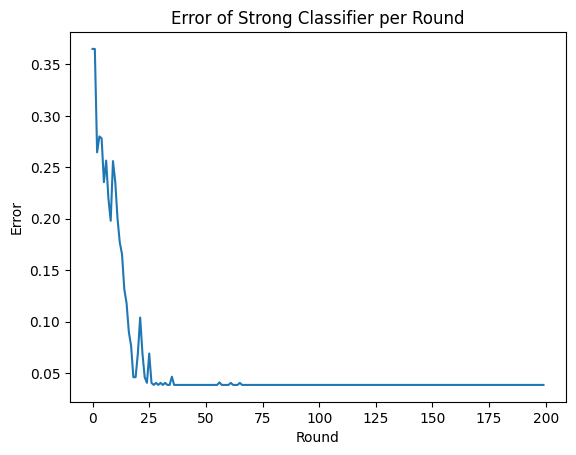

In [5]:
"""
Train, combine, and visualize multiple weak classifiers
"""

# TODO generate data
data, targets = gen_data(n_samples)

# TODO initialize sample weights
weights = np.ones(n_samples) / n_samples

# TODO initialize arrays or lists for storing the alphas, predictions, decision_boundaries, errors and classifiers
alphas = np.zeros(n_classifiers)
predictions_weak = np.zeros((n_samples, n_classifiers)) # Renamed to avoid confusion with internal 'predictions' variable in loop
decision_boundaries = np.zeros((n_classifiers, 12**2))
errors = np.zeros(n_classifiers)
classifiers = list()

for t in range(n_classifiers):
    # TODO train weak classifier
    classifier = Classifier()
    classifier = train_classifier(classifier, data, targets, weights)
    classifiers.append(classifier)

    # TODO compute predictions of the weak classifier
    predictions_current_weak = classifier.predict(data)

    # TODO calculate the weighted! training error of the weak classifier
    error_weak = (weights * (predictions_current_weak != targets).astype(int)).sum()

    # TODO calculate alpha
    if error_weak == 0:
      alpha = np.inf # Classifier is perfect, assign very high weight
    elif error_weak == 1:
        alpha = -np.inf # Classifier is perfectly wrong, assign very high negative weight
    else:
        alpha = 0.5 * np.log((1 - error_weak) / error_weak)

    # Store alpha for the current classifier
    alphas[t] = alpha

    # TODO update weight distribution for samples (note: normalization)
    weights = weights * np.exp(-alpha * targets * predictions_current_weak)
    weights = weights / weights.sum()

    # TODO calculate the error of the final strong classifier (so far)
    strong_predictions_on_data = np.zeros(n_samples)
    for i in range(t + 1): # Iterate through all classifiers trained up to this round 't'
        strong_predictions_on_data += alphas[i] * classifiers[i].predict(data)
    strong_predictions_on_data = (strong_predictions_on_data > 0).astype(int) * 2 - 1
    error_strong_classifier = (strong_predictions_on_data != targets).astype(int).sum() / n_samples
    errors[t] = error_strong_classifier

    # TODO compute the decision boundary of the current strong classifier (so far)
    decision_boundaries[t] = get_decision_boundary(data, classifiers[:t+1], alphas[:t+1]).flatten()

# TODO plot the error of the final strong classifiers for each round
plt.plot(errors)
plt.xlabel('Round')
plt.ylabel('Error')
plt.title('Error of Strong Classifier per Round') # Added a title for clarity
plt.show()

In [1]:
'''animation = Animation(data, targets, decision_boundaries)
HTML(animation.get_animation().to_jshtml())'''

'animation = Animation(data, targets, decision_boundaries)\nHTML(animation.get_animation().to_jshtml())'

## Exercise 4.2: Filter Matrix

Given a $2 \times 4$ image
\begin{equation}
\mathbf{X} =
\begin{bmatrix}
    a &b &c &d \\
    e &f &g &h \\
\end{bmatrix}
\end{equation}

and a $1 \times 3$ filter kernel
\begin{equation}
\mathbf{K} =
\begin{bmatrix}
    -1 &0 &1
\end{bmatrix},
\end{equation}
write down the [filter operation](https://www.deeplearningbook.org/contents/convnets.html) as a matrix multiplication $\mathbf{y} = \mathbf{W}_{k} \mathbf{x}$.

1. What is the output image $\mathbf{Y}$ when filtering $\mathbf{X}$ with $\mathbf{K}$?
2. Flatten $\mathbf{X}$ into an 8-dimensional vector ($8 \times 1$) $\mathbf{x}$ by concatenating each matrix row.
3. Create a matrix $\mathbf{W}_{k}$ such that $\mathbf{W}_{k} \mathbf{x}$ returns a 4-dimensional vector $\mathbf{y}$ that can be reshaped into $\mathbf{Y}$.
4. For a filter operation with the same dimensions as in (3.), how does the weight matrix $\mathbf{W}$ for any single $1 \times 3$ kernel of a convolution layer look like?
5. Can a hidden layer of a multilayer perceptron (MLP) learn the filter operation mentioned above? What are the differences between the weight matrix of a hidden layer $\mathbf{H}$ and a convolution layer $\mathbf{W}$?
6. Suppose you have two classification models for a two-class dataset consisting of several $2 \times 4$ images: an MLP $\sigma ( \mathbf{M}(ReLU(\mathbf{H} \mathbf{x})))$ and a convolutional neural network (CNN) $\sigma ( \mathbf{M}(ReLU(\mathbf{W} \mathbf{x})))$, both having an additional $4 \times 1$ output matrix $\mathbf{M}$. With $\sigma$ being the sigmoid function, both models produce a score $s \in [0, 1]$ denoting whether an input image $\mathbf{x}$ belongs to a class A ($s=1$) or to a class B ($s=0$). After training, both models reach a training accuracy of 100%. Without further testing, which model would you prefer to use in production and why?

Answer the following comprehension questions either with right or wrong and briefly explain your decision:

1. Multiplying the matrix output with a negative scalar is a valid non-linearity for deep networks.

wrong

2. If the input data are distributed uniformly, and a small latent dimension is chosen, an Autoencoder behaves similarly to a PCA.

right

3. To obtain a faster, albeit slightly less effective, version of AdaBoost, one can omit readjusting the sample weights during an iteration step.

wrong

4. To effectively train a CNN committee, different training datasets (bagging) or architectures are needed; otherwise, each network learns the same weights.

wrong

5. To separate five different classes with AdaBoost, you need to train 5 AdaBoost classifiers for one-versus-all and 9 AdaBoost classifiers for one-versus-one.


wrong